In [1]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles
using PyCall

In [2]:
num = 5
c = 0.5
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Bodewadt.txt",199,0,0.115,30,1,0)
nep = PEP([A0,A1,A2,A3,A4]); 
eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval

5-element Vector{ComplexF64}:
 0.38766205817173616 + 0.006569127990461572im
  0.5102210689494189 + 0.056295434268221166im
  0.3864912359433544 - 0.5210093156805302im
   0.138056644910806 - 0.09270169076238534im
 0.14431958476227874 - 0.17507467030455293im

In [8]:
Tw = 1
N_cheb = 149
Mr = 0.3
gamma = 1.4
sigma = 0.72
omega = 0.024
R = 33.5
c = 0.6
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,0);
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim");
lam = - (2/3) * T
kappa = (1/sigma) * T
num = 1
be = 0.153
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,1,0)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep , σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval = conj(eigval)

1-element Vector{ComplexF64}:
 0.6047785205403375 - 0.00047066826447059526im

In [9]:
u_hat = [0;eigvec[1:N_cheb-1,1];0]
v_hat = [0;eigvec[N_cheb:2N_cheb-2,1];0]
w_hat = [0;eigvec[2N_cheb-1:3N_cheb-3,1];0]
rho_hat = [0;eigvec[3N_cheb-2:4N_cheb-4,1];0]
T_hat = [0;eigvec[4N_cheb-3:5N_cheb-5,1];0]

150-element Vector{ComplexF64}:
                     0.0 + 0.0im
   -1.092909312127795e-7 - 4.369462695534717e-8im
   -4.372563407304326e-7 - 1.7480500605826163e-7im
   -9.841522770575085e-7 - 3.934389772210635e-7im
  -1.7503988375645963e-6 - 6.997496329842149e-7im
  -2.7366201583556436e-6 - 1.0939709798109569e-6im
   -3.943536961612051e-6 - 1.57638560801225e-6im
   -5.372150669527179e-6 - 2.1473206622129453e-6im
   -7.023436693217133e-6 - 2.807189498132967e-6im
   -8.898751525938034e-6 - 3.5563810133264033e-6im
                         ⋮
  -3.379130740717754e-11 + 6.57463850072329e-11im
  1.9014717965487508e-11 - 3.7636167877423514e-11im
  -9.956138153175358e-12 + 2.2040287184308532e-11im
   4.395063063463835e-12 - 6.017721260534459e-12im
 -1.8765262313440857e-12 + 5.247837104108144e-12im
    6.07013041877065e-13 - 2.347797791683176e-12im
 -1.1595649369511047e-13 + 3.649234133460983e-13im
  1.0953876459534386e-13 - 2.0002123872139843e-12im
                     0.0 + 0.0im

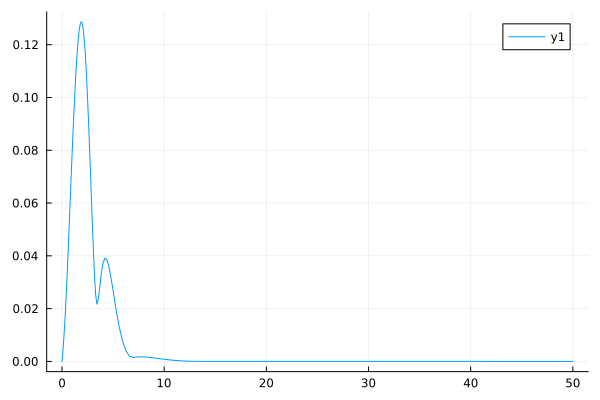

In [12]:
plot(x,abs.(v_hat))

In [92]:
##DIRECTLY CACULATE CUR
##initial
for Tw = 1
    N_cheb = 149
    omega = -0.1
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    global R = 26
    R_step = 0.25
    be1 = 0.005
    be_step = -0.001
    c = 0.7
    num = 1
    Ro = 1
    Co = 0
    Ma = Mr/R
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    global initial_i = []
    global initial_r = []
    global tempvec_i = [0 0 0 0]
    global tempvec_r = [0 0 0 0]
    global mode = 0
    writedlm("output_$Tw _ $Mr.dat",initial_i)
    writedlm("output_eig.dat",initial_r)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
    eigval = conj(eigval)
    if imag(eigval[1]) < 0
        for be = be1 : -1 * be_step : 0.5

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
        eigval = conj(eigval)
        point = filter(x ->  - 0.001 < imag(x) < 0.0005, eigval)
        open("output_eig.dat", "a") do io
            write(io,"be=$be,eig=$eigval\n")
        end
        if point != []
            global initial_i = [omega R be imag(point)]
            global initial_r = [omega R be real(point)]
            break
        end
        end
    elseif imag(eigval[1]) > 0
        for be = be1 : 1 * be_step : -0.1

            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
            eigval = conj(eigval)
            point = filter(x ->  - 0.001 < imag(x) < 0.0005, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
        end
    end
    global total_r = initial_r
    global total_i = initial_i

# CACULATE

    for be = initial_r[1,3] +  be_step  :  be_step : -0.2
        if total_i[end,2] <40
            num = 5
        else
            num = 1
        end
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 2 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_1 = conj(eigval_1)
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be - 2 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_2 = conj(eigval_2)
        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

        global mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

        global mode = 2

        end
        
        if length(total_r[:,1]) > 2 

           grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
        else

           grad = 0

        end
        

        if mode == 1 



            for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 0
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                pre = total_r[end,4] - im * total_i[end,4]
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)
                index = findmin(abs.(imag(eigval)))
                global tempvec_i = [tempvec_i;[omega R be index[2]]]
                global tempvec_r = [tempvec_r;[omega R be index[2]]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end- 1 ,4] * index[2] < 0

                    global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                    global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]

                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    
                    break
                end
                
                if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                    mode = 2
                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    break
                    
                end
            end        
        end


        if mode == 2

            for R = total_r[end,2] + 0 * grad * be_step: R_step : 600
            
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)
                index = findmin(abs.(imag(eigval)))
                global tempvec_i = [tempvec_i;[omega R be index[2]]]
                global tempvec_r = [tempvec_r;[omega R be index[2]]]


                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * index[2] < 0
                    global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                    global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break

                end

                if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                    global mode = 1
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                    
                end
            end
        end

        if mode == 1
            
            for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
              
                if total_i[end,3] == be

                    break

                end 

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)
                index = findmin(abs.(imag(eigval)))
                global tempvec_i = [tempvec_i;[omega R be index[2]]]
                global tempvec_r = [tempvec_r;[omega R be index[2]]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * index[2] < 0
                    global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                    global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                end
                
                if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                global mode = 2
                global tempvec_i = [0 0 0 0]
                global tempvec_r = [0 0 0 0]
                    break
                    
                end

            end     
        end
 
        if total_i[end,2]>510 && size(total_i,1)>100
            break
        end
        # if total_i[end,2]>total_i[end-1,2]
        #     break
        # end

    end

    writedlm("$omega _Netwon_$Tw _$Mr _i.dat",total_i)
    writedlm("$omega _Netwon_$Tw _$Mr _r.dat",total_r)

    end


InterruptException: InterruptException:

In [3]:
#convert
for Tw = 0.8 
    N_cheb = 149
    omega = 0.024
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    global R = 100
    R_step = 0.1
    be1 = 0.12
    be_step = 0.0002
    c = 0.05
    num = 1
    Ro = 1
    Co = 0
    Ma = Mr/R
    
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num = 1
    global initial_i = []
    global initial_r = []
    global tempvec_i = [0 0 0 0]
    global tempvec_r = [0 0 0 0]
    global mode = 0
    writedlm("output_$Tw _ $Mr.dat",initial_i)
    writedlm("output_eig.dat",initial_r)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
    eigval = conj(eigval)
    if imag(eigval[1]) < 0
        for be = be1 : -0.25*be_step : -0.15

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
        eigval = conj(eigval)
        point = filter(x ->  - 0.0003 < imag(x) < 0.0003, eigval)
        open("output_eig.dat", "a") do io
            write(io,"be=$be,eig=$eigval\n")
        end
        if point != []
            global initial_i = [omega R be imag(point)]
            global initial_r = [omega R be real(point)]
            break
        end
        end
    elseif imag(eigval[1]) > 0
        for be = be1 : 0.25*be_step : 0.5

            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
            eigval = conj(eigval)
            point = filter(x ->  - 0.0003 < imag(x) < 0.0003, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
        end
    end
    global total_r = initial_r
    global total_i = initial_i

# CACULATE

    for be = initial_r[1,3] +  be_step  :  be_step : 0.4

        pre = total_r[end,4] - im * total_i[end,4]
        
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_1 = conj(eigval_1)
        
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_2 = conj(eigval_2)
        
        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

        global mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

        global mode = 2

        end
        
        if length(total_r[:,1]) > 2 

           grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
        else

           grad = 0

        end
        
        if mode == 1 

            for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 0

                if be - total_i[end,3] >2 * be_step
                    pre = 0.5
                    num = 1
                else 
                    num = 1
                end
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0 || abs(imag(eigval[1])) < 0.0001

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]


                    global tempvec_i = [tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]
                    global tempvec_r = [tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]
                    break

                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    mode = 2

                    global tempvec_i = [tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]
                    global tempvec_r = [tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]
                    break
                    
                end
            end        
        end


        if mode == 2

            for R = total_r[end,2] + 0 * grad * be_step: R_step : 600
                if be - total_i[end,3] >2 * be_step
                    pre = 0.5
                    num = 1
                else 
                    num = 1
                end
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0 || abs(imag(eigval[1])) < 0.0001

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]


                    global tempvec_i = [tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]
                    global tempvec_r = [tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]
                    break

                end

                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    global mode = 1

                    global tempvec_i = [tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]
                    global tempvec_r = [tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]
                    break
                    
                end
            end
        end

        if mode == 1
            
            for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
                if be - total_i[end,3] >2 * be_step
                    pre = 0.5
                    num = 1
                else 
                    num = 1
                end
                if total_i[end,3] == be

                    break

                end 

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)
     
                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0 || abs(imag(eigval[1])) < 0.0001

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]


                    global tempvec_i = [tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]
                    global tempvec_r = [tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]
                    break

                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                global mode = 2
                global tempvec_i = [tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]
                global tempvec_r = [tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]
                    break
                    
                end

            end     
        end
 
        if total_i[end,2]>110 && size(total_i,1)>10
            break
        end
        # if total_i[end,2]>total_i[end-1,2]
        #     break
        # end

    end
    writedlm("$omega _Netwon_$Tw _$Mr _i.dat",total_i)
    writedlm("$omega _Netwon_$Tw _$Mr _r.dat",total_r)
    end


┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

InterruptException: InterruptException:

In [47]:
B = [1 0 ; 0 1 ; 1 -1]
C = [1 0 -1 ; 0 1 -1]
A = [1 0 -1;0 1 -1;1 -1 0]
D = C' * inv(C * C') * inv(B' * B) * B'
A * D

3×3 Matrix{Float64}:
 0.666667   0.333333   0.333333
 0.333333   0.666667  -0.333333
 0.333333  -0.333333   0.666667

In [4]:
writedlm("Test_i.dat",total_i)
writedlm("Test_r.dat",total_r)

In [ ]:
#FOR CR wavenumber
for Tw = 1
    N_cheb = 149
    omega = 0.08
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    global R = 35
    R_step = 0.2
    be1 = 0.2
    be_step = -0.0002
    c = 0.5
    num = 1
    Ro = 1
    Co = 0
    Ma = Mr/R
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num = 1
    global initial_i = []
    global initial_r = []
    global tempvec_i = [0 0 0 0]
    global tempvec_r = [0 0 0 0]
    global mode = 0
    writedlm("output_$Tw _ $Mr.dat",initial_i)
    writedlm("output_eig.dat",initial_r)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
    eigval = conj(eigval)
    if imag(eigval[1]) < 0
        for be = be1 : -0.25 * be_step : 0.5

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
        eigval = conj(eigval)
        point = filter(x ->  - 0.0005 < imag(x) < 0.0005, eigval)
        open("output_eig.dat", "a") do io
            write(io,"be=$be,eig=$eigval\n")
        end
        if point != []
            global initial_i = [omega R be imag(point)]
            global initial_r = [omega R be real(point)]
            break
        end
        end
    elseif imag(eigval[1]) > 0
        for be = be1 : 0.25 * be_step : -0.1

            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
            eigval = conj(eigval)
            point = filter(x ->  - 0.0005 < imag(x) < 0.0005, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
        end
    end
    global total_r = initial_r
    global total_i = initial_i

# CACULATE

    for be = initial_r[1,3] +  be_step  :  be_step : -0.2

        if abs.(total_i[end,3] - be) > 5 * be_step
            pre = 0.5
        else
            pre = total_r[end,4] - im * total_i[end,4]
        end

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 2 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_1 = conj(eigval_1)
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be - 2 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_2 = conj(eigval_2)
        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

        global mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

        global mode = 2

        end
        
        if length(total_r[:,1]) > 2 

           grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
        else

           grad = 0

        end
        
        if mode == 1 



            for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 0
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 

                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end- 1 ,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]

                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    
                    break
                end
                
                if len > 5 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-1,4])

                    mode = 2
                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    break
                    
                end
            end        
        end


        if mode == 2

            for R = total_r[end,2] + 0 * grad * be_step: R_step : 600
            
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break

                end

                if len > 5 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-1,4])

                    global mode = 1
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                    
                end
            end
        end

        if mode == 1
            
            for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
              
                if total_i[end,3] == be

                    break

                end 

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)
     
                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                end
                
                if len > 5 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-1,4])

                global mode = 2
                global tempvec_i = [0 0 0 0]
                global tempvec_r = [0 0 0 0]
                    break
                    
                end

            end     
        end
 
        if total_i[end,2]>110 && size(total_i,1)>100
            break
        end
        # if total_i[end,2]>total_i[end-1,2]
        #     break
        # end

    end

    writedlm("$omega _Netwon_$Tw _$Mr _i.dat",total_i)
    writedlm("$omega _Netwon_$Tw _$Mr _r.dat",total_r)

    end


InterruptException: InterruptException:

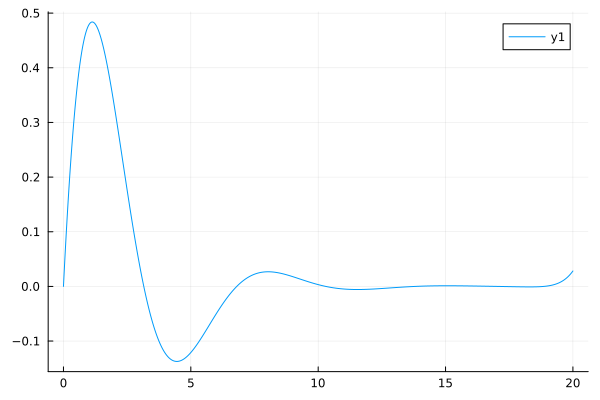

In [220]:
Ro = 1
Co = 0
tspan = (0,20)
Num = 10001
function oneDiskODE!(du, u , p, t)
                
    # U = u[1]
    # dU = u[2]
    # V = u[3]
    # dV = u[4]
    # W = u[5]
    # du[1] = dU
    # ddU = Ro*(U^2 + W*dU - (V^2 - 1e0)) - Co*(V + 1.0e0)
    # du[2] = ddU
    # ddV = Ro*(2*U*V + W*dV) + Co*(U)
    # du[3] = dV
    # du[4] = ddV                          
    # du[5] = -2.0e0*U
    U = u[1]
    dU = u[2]
    V = u[3]
    dV = u[4]
    W = u[5]
    du[1] = dU
    ddU = Ro*(U^2 + W*dU - (V^2 - 1)) - Co*(V - 1.0)
    du[2] = ddU
    ddV = Ro*(2*U*V + W*dV) + Co*U
    du[3] = dV
    du[4] = ddV                          
    du[5] = -2.0*U

end
function oneDiskbc!(residual, u , p, t)

    residual[1] = u[begin][1] 
    residual[2] = u[begin][3] 
    residual[3] = u[begin][5] 

    residual[4] = u[end][1] 
    residual[5] = u[end][3] - 1

end
    if Ro == 1
        ini = [0.0 , -9.419709011708589097e-01, 0.0,7.728853782538425143e-01, 0.0]
    elseif Ro == 0
        ini = [0.0 , -1, 0.0, 1, 0.0]
    else 
        ini = [0.0, -0.51, 0.0, 0.6159, 0.0]
    end
    # if Ro + Co == -1
    #     ini = [0.0 , 0.942 , 0.0 , -0.7729, 0.0]
    # elseif Ro + Co== 2
    #     ini = [0.0 , 1.0, 0.0, -1.0, 0.0]
    # else 
    #     ini = [0.0, 0.51, 0.0, -0.6159, 0.0]
    # end
    prob = BVProblem(oneDiskODE!, oneDiskbc!, ini,tspan, dtmax=0.01)
    sol = solve(prob, Shooting(Vern7()))
    t=range(0.0, 20, Num)
    u= -1 * sol(t)
    plot(t,u[1,:])

In [ ]:
py"""
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
kappa = 1
def oneDiskODE(z, y):

        # Y0 = H, Y1 = F', Y2 = F, Y3 = G', Y4 = G
        dydz = np.zeros((5, len(z)))
        dydz = np.array([-
                        2.0*
                        y[2], kappa * 
                        (y[2] *
                        y[2] +
                            y[0] *
                            y[1] -
                            (y[4] *
                            y[4]- 
                            1.0)) -
                        (2.0 -
                            kappa - 
                            kappa**2) *
                        (y[4] -
                            1.0), y[1], kappa *
                        (2.0 * 
                            y[2] *
                            y[4] +
                            y[0] *
                            y[3]) +
                        (2.0 -
                            kappa -
                            kappa**2) *
                        y[2], y[3]])
        return dydz 

def oneDiskBC(ya, yb):
        resa = np.array([ya[0],
                        ya[2],
                        ya[4]])
        
        resb = np.array([yb[2],
                        yb[4] - 1.0])
        
        return np.concatenate((resa, resb))


z = np.linspace(0, 50, 20000)
y = np.zeros((5, len(z)))
y_guess = np.zeros((5, z.size))
if kappa == 1:
        y_guess[0] = 1.2
        y_guess[1] = 0
        y_guess[2] = 0
        y_guess[3] = 0
        y_guess[4] = 1
elif kappa == -1:
        y_guess[0] = 1.2
        y_guess[1] = 0
        y_guess[2] = 0
        y_guess[3] = 0
        y_guess[4] = 1
else:
        y_guess[0] = 1.2
        y_guess[1] = 0
        y_guess[2] = 0
        y_guess[3] = 0
        y_guess[4] = 1




solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,tol=1e-10,max_nodes=5000000)

x_plot = np.linspace(0, 50, 20000)


y1_plot = solution.sol(x_plot)[0]
y2_plot = solution.sol(x_plot)[2]
y3_plot = solution.sol(x_plot)[4]
y4_plot = solution.sol(x_plot)[1]
y5_plot = solution.sol(x_plot)[3]




"""

ArgumentError: ArgumentError: Package numpy not found in current path.
- Run `import Pkg; Pkg.add("numpy")` to install the numpy package.